In [10]:
import pandas as pd
import glob
import numpy as np

clean_files = glob.glob("Runs/*_clean.csv")

results = []

for file in clean_files:

    df = pd.read_csv(file)

    model = (
        file.split("\\")[-1]
        .replace("Runs_", "")
        .replace("_clean.csv", "")
    )

    if "accuracy" not in df.columns:
        continue

    df["accuracy"] = pd.to_numeric(
        df["accuracy"],
        errors="coerce"
    )

    best = df.loc[
        df["accuracy"].idxmax()
    ]

    results.append({

        "Model": model,

        "Accuracy":
            float(best["accuracy"]),

        "Precision":
            float(best["training_precision_score"])
            if "training_precision_score" in df.columns
            else np.nan,

        "Recall":
            float(best["training_recall_score"])
            if "training_recall_score" in df.columns
            else np.nan,

        "F1":
            float(best["training_f1_score"])
            if "training_f1_score" in df.columns
            else np.nan

    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Stacking,0.793067,0.824285,0.826417,0.817527
1,KNN,0.785965,0.834104,0.830251,0.830753
2,SVM,0.767529,0.798300,0.768729,0.748493
3,GradientBoosting,0.759309,0.776989,0.760493,0.737490
4,Bagging,0.759067,0.779611,0.770145,0.754232
5,Neural_Networks,0.758825,0.753758,0.757046,0.736496
6,XGBoost,0.757949,NaN,NaN,NaN
7,Decision_Trees,0.755228,0.731571,0.756205,0.735984
8,AdaBoost,0.748640,0.703126,0.747270,0.722266
9,Naive_Bayes,0.733771,0.673468,0.730780,0.683675


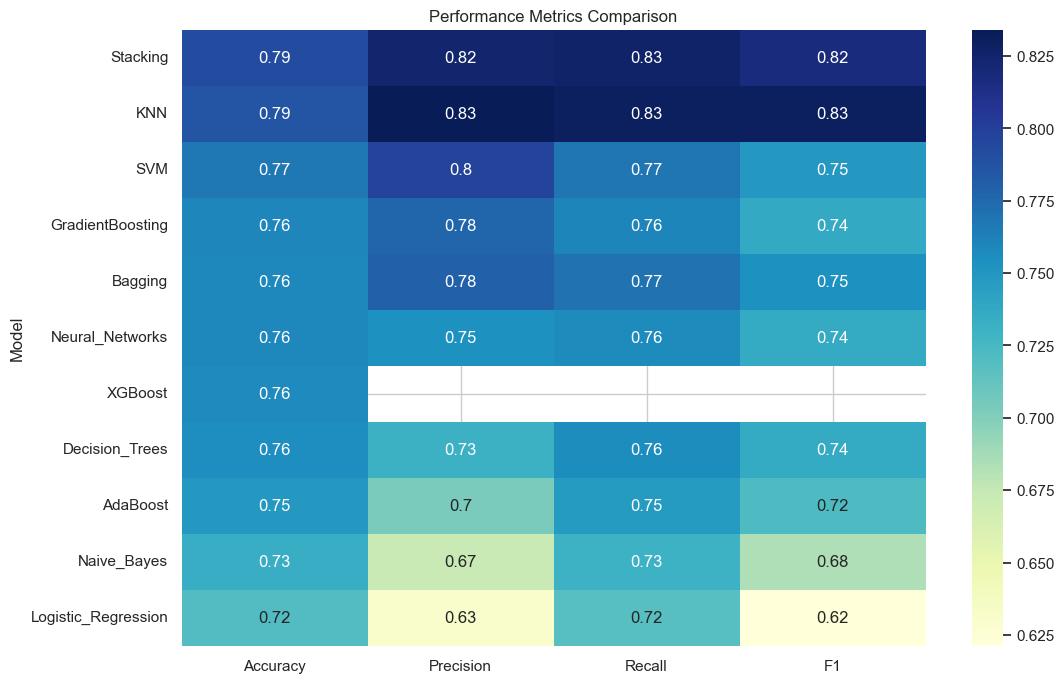

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = (
    results_df
    .set_index("Model")
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="YlGnBu"
)

plt.title(
    "Performance Metrics Comparison"
)

plt.show()

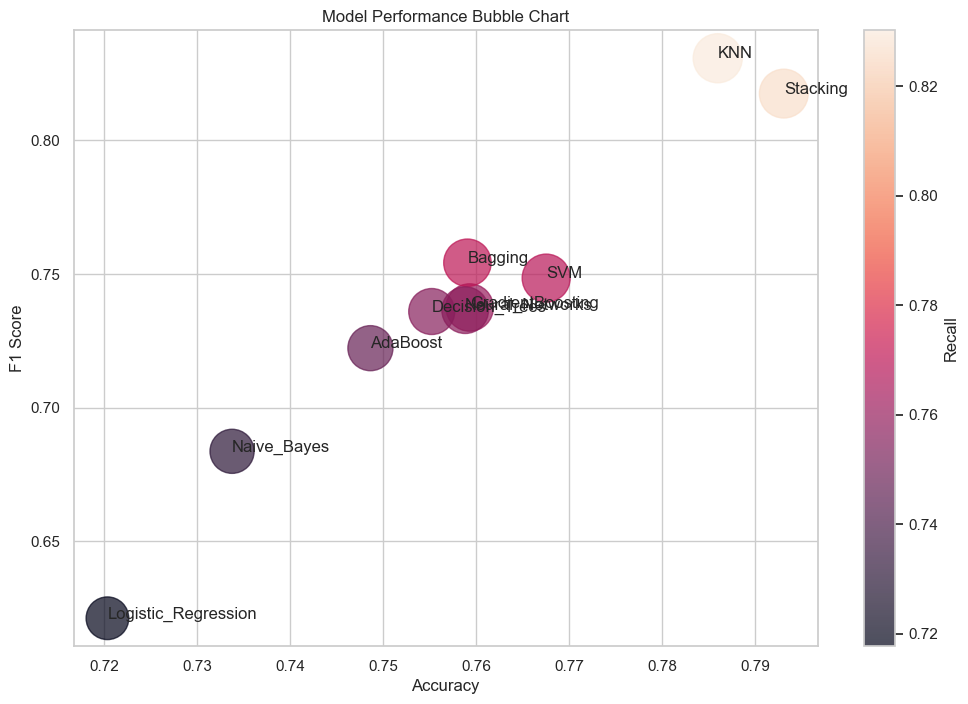

In [17]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    results_df["Accuracy"],
    results_df["F1"],
    s=results_df["Precision"]*1500,
    c=results_df["Recall"],
    alpha=0.7
)

for _, row in results_df.iterrows():

    plt.annotate(
        row["Model"],
        (
            row["Accuracy"],
            row["F1"]
        )
    )

plt.colorbar(
    scatter,
    label="Recall"
)

plt.xlabel("Accuracy")
plt.ylabel("F1 Score")
plt.title("Model Performance Bubble Chart")

plt.show()

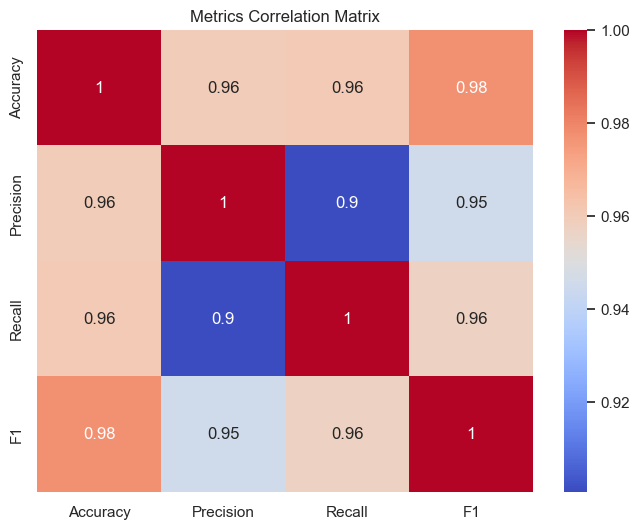

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    results_df[
        ["Accuracy","Precision","Recall","F1"]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Metrics Correlation Matrix")

plt.show()

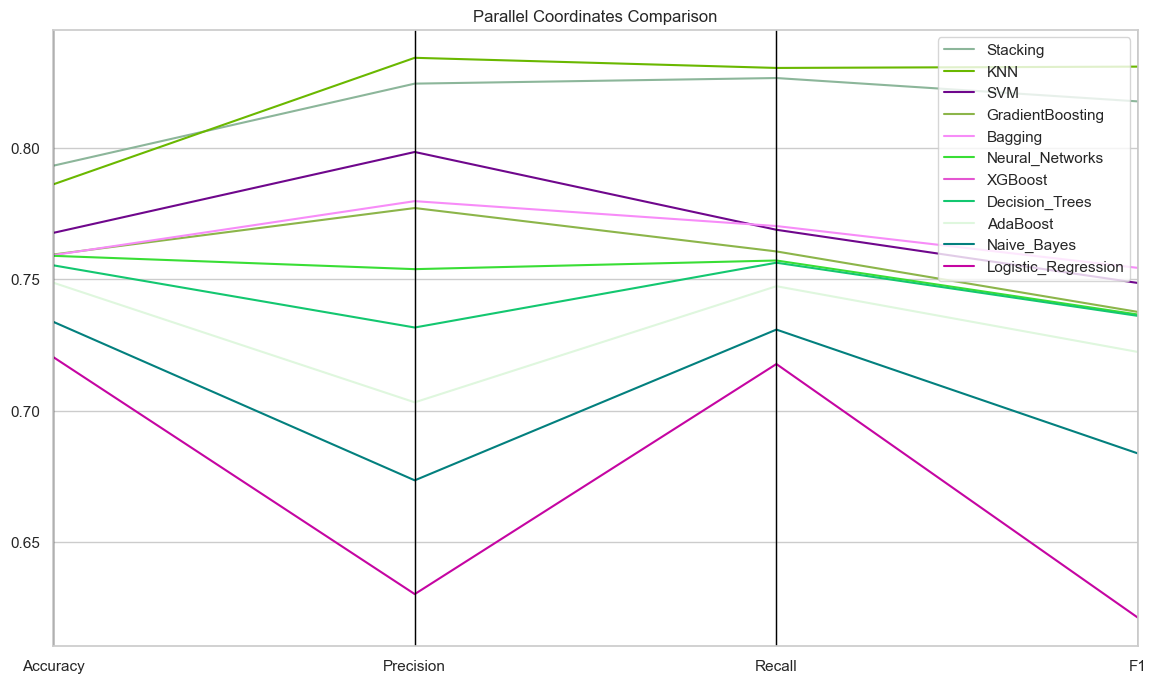

In [19]:
from pandas.plotting import parallel_coordinates

plot_df = results_df.copy()

plt.figure(figsize=(14,8))

parallel_coordinates(
    plot_df,
    "Model",
    cols=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

plt.title("Parallel Coordinates Comparison")

plt.grid()

plt.show()

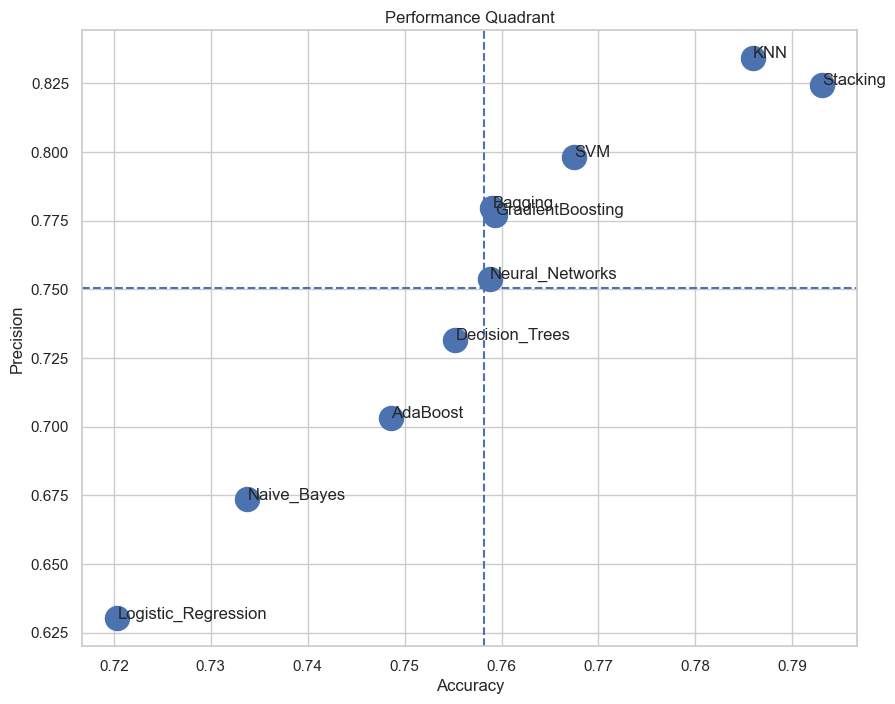

In [21]:
plt.figure(figsize=(10,8))

plt.scatter(
    results_df["Accuracy"],
    results_df["Precision"],
    s=300
)

for _, row in results_df.iterrows():

    plt.annotate(
        row["Model"],
        (
            row["Accuracy"],
            row["Precision"]
        )
    )

plt.axvline(
    results_df["Accuracy"].mean(),
    linestyle="--"
)

plt.axhline(
    results_df["Precision"].mean(),
    linestyle="--"
)

plt.xlabel("Accuracy")
plt.ylabel("Precision")

plt.title(
    "Performance Quadrant"
)

plt.show()

In [16]:
best = results_df.iloc[0]

print(
f"""
Best Model: {best['Model']}

Accuracy: {best['Accuracy']:.4f}
Precision: {best['Precision']:.4f}
Recall: {best['Recall']:.4f}
F1 Score: {best['F1']:.4f}
"""
)


Best Model: Stacking

Accuracy: 0.7931
Precision: 0.8243
Recall: 0.8264
F1 Score: 0.8175



# Analysis of Precision, Recall and F1-Score

## Metrics Table Analysis - 1º Tabela

A tabela inicial permite observar o desempenho dos diferentes modelos de Machine Learning através das métricas Accuracy, Precision, Recall e F1-Score.

Analisando os resultados, conseguimos perceber que o modelo Stacking apresentou o melhor desempenho global, alcançando uma accuracy de aproximadamente 79.3%, bem como valores elevados de Precision (82.4%), Recall (82.6%) e F1-Score (81.8%).

O modelo KNN apresentou resultados muito próximos dos obtidos pelo Stacking, acabando por se destacar e obter melhores resultados em 3 dos critérios (apesar de os resultados andarem muito próximos uns dos outros), Precision = 83.4, Recall = 83 e F1 = 83

Por outro lado, a Logistic Regression apresentou os resultados mais baixos em todas as métricas, enquanto o Naive Bayes demonstrou um desempenho intermédio, superior à Regressão Logística mas inferior aos restantes modelos.

De uma forma geral, os métodos Ensemble e os algoritmos baseados em vizinhança apresentaram um desempenho superior aos modelos lineares mais simples.

## Heatmap Analysis

O gráfico do Heatmap permitiu-nos identidicar as difrenças notáveis entre os modelos e as métreicas.  Conseguimos perceber que os tons mais escuros são os que apresentam melhores resultados, neste caso o Stacking e o KNN. Já os modelos intermédios, como o SVM, Bagging, Gradient Boosting  e Neural Networks também apresentam um bom equilibrio entre eles. ~

Modelos com cores mais claras, como é o caso do Naive Bayes e da Logistic Regression refletem desempenhos inferiores relativamente aos restantes algoritmos. Com este gráfico temos uma maior facilidade na identidicação visual dos modelos com melhor capacidade de classificação, sem existir a necessidade de analisar individualmente cada valor numérico.



## Bubble Chart Analysis

O seguinte gráfico que é o Bubble Chart permite representar as 4 métricas pedidas, permitindo que visualmente a análise seja mais atrativa:

    . Accuracy (eixo horizontal)
    . F1-Score (eixo vertical)
    . Precision (tamanho da bolha)
    . Recall (cor da bolha)

Com estas informações torna-se mais fácil a identificação. Os modelos Stacking e KNN encontram-se isolados no canto superior direito, o que nos indica que possuem valores elevados de Accurcy e de F1. Depois verificamos também que o tamanho das bolhas é maior e que a sua cor é mais suave (mais clarinha), o que indica valores mais elevados de Precision e de Recall.

Contudo outros modelos como o Logistic e o Naive Bayes encontram-se no canto inferior esquerdo e com cores mais escuras, ou seja, possuem um desempenho mais reduzido. Este gráfico ajuda a confirmar que os modelos mais bem classificados, conseguem manter simultaneamente um bom equilíbrio entre todas as métricas avaliadas.

## Correlation Matrix Analysis

A seguinte análise é relativa à matriz de correlação, e permite analisar a relação existente entre as métricas utilziadas. As métricas quando comparadas com elas mesmas apresentam o valor de 1, o que era de esperar. Excluindo isso, a maior correlação foi entre a Accuracy e o F1, indicando que modelos com elevada accuracy tendem também a apresentar valores elevados de F1.

Depois de analisado o gráfico percebemos que os as métricas apresentam todas valores de correlção muito próximos uns dos outros, o que nos indica que todas as métricas estão bastante correlacionadas umas com as outras.

## Parallel Coordinates Analysis

Agora falamos do gráfico que possui várias linhas, uma linha para cada modelo e mostra como o modelo variou de acordo com as diferentes métricas. Mais uma vez observamos que os modelos Stacking e KNN são os melhores, começando um pouco a subir na Accuracy, mas mantendo um desempenho constante nas restantes métricas. 

Depois os modelos intermédios, mantendo linhas também posiciondas na parte mais suoerior do gráfico, mostra que os modelos (SVM, Bagging, Gradient Boosting e Neural Networks) apresentam também trajétorias semelhantes, ou seja, possuem um bom equilibrio entre elas.

Em contraste, os modelos Naive Bayes e Logistic Regression apresentam linhas localizadas em níveis inferiores, confirmando os resultados observados anteriormente. Este gráfico evidencia que não existe apenas uma métrica onde os melhores modelos se destacam, mas sim um desempenho superior de forma consistente ao longo de todas as métricas avaliadas.



## Performance Quadrant Analysis

Para terminar, o último gráfico a analisar, mostra que o gráfico foi dividido em 4 regiões . Os modelos que estão dentro do quadrante superior direito apresentam valores acima da média em ambas as métricas, sendo considerados os modelos com melhor desempenho global.

Mais uma vez, neste grupo aparecem os modelos Stacking, KNN, SVM, Bagging, Gradient Boosting. Por outro lado, modelos como Logistic Regression, Naive Bayes e AdaBoost encontram-se abaixo das médias consideradas, demonstrando um desempenho relativamente inferior. Este gráfico permite identificar rapidamente quais os modelos que conseguem combinar simultaneamente elevada Accuracy e elevada Precision.


## Conclusion

A recorrente análise das métricas e dos gráficos permitiu concluir que o modelo Stacking apresentou o melhor desempenho global, seguido de perto pelo KNN e pelo SVM. Os resultados mostram também que os métodos Ensemble, nomeadamente Stacking, Bagging e Gradient Boosting, conseguiram obter classificações mais robustas quando comparados com modelos mais simples, como a Logistic Regression e o Naive Bayes. De uma forma geral, os modelos com melhor desempenho conseguiram manter simultaneamente valores elevados de Accuracy, Precision, Recall e F1-Score, demonstrando uma maior capacidade para classificar corretamente os níveis de satisfação profissional presentes no dataset.